## Part 1 : Dataset Overview & Composition

Before analyzing model vulnerabilities, we first validate the scale and distribution of our generated dataset. 

Because our labeling pipeline generates multiple rows per span (one for each LLM evaluation), we must isolate the unique questions and spans to avoid double-counting. The following output provides a high-level summary of our dataset's structural composition, detailing the total number of problems evaluated and the distribution of our targeted linguistic categories across the math and logic subsets.

In [4]:
import pandas as pd

# Load data
df = pd.read_csv("../data/consensus_dataset.csv")

# Isolate unique questions and unique spans
unique_questions = df.drop_duplicates(subset=["example_id"])
unique_spans = df.drop_duplicates(subset=["example_id", "span_start", "span_end"])

print("=== 1. DATASET OVERVIEW ===")
print(f"Total Unique Questions: {len(unique_questions)}")
print(f"Total Unique Candidate Spans: {len(unique_spans)}")

print("\n--- Spans by Source Dataset ---")
print(unique_spans['source_dataset'].value_counts().to_string())

print("\n--- Spans by Linguistic Category ---")
print(unique_spans['span_category'].value_counts().to_string())

=== 1. DATASET OVERVIEW ===
Total Unique Questions: 924
Total Unique Candidate Spans: 14162

--- Spans by Source Dataset ---
source_dataset
gsm_ic                                         3153
gsm8k                                          2854
bbh_tracking_shuffled_objects_three_objects    2456
bbh_navigate                                   1526
bbh_formal_fallacies                           1398
bbh_date_understanding                         1176
bbh_logical_deduction_three_objects            1125
bbh_object_counting                             474

--- Spans by Linguistic Category ---
span_category
action_verb               3930
entity                    3316
number                    3194
random_control            2762
comparison_conditional     416
negation                   358
distractor_context         186


## Part 2 : Visualizing LLM Vulnerabilities (Exploratory Data Analysis)

Now that we have our aggregated `consensus_dataset.csv`, let's break down exactly *why* the models fail when certain tokens are dropped. 

The goal of this EDA is to prove that prompt criticality is highly contextual—which justifies our plan to build a smart RoBERTa-based compressor rather than relying on a naive random-deletion rule. 

This cell generates a 2x2 grid analyzing four specific angles:
1. **Dataset Fragility:** Are math problems (GSM8K) inherently more sensitive to token deletion than logic puzzles (BBH)?
2. **Linguistic Vulnerability:** Which specific missing words (numbers, verbs, entities) actually break the reasoning chain?
3. **Model-Specific Failure Rates:** Do Qwen, Groq (GPT-OSS), and GLM share the exact same weaknesses?
4. **Consensus Distribution:** Do the models unanimously agree on what is "critical," or is there a spectrum of uncertainty that our scorer needs to learn?

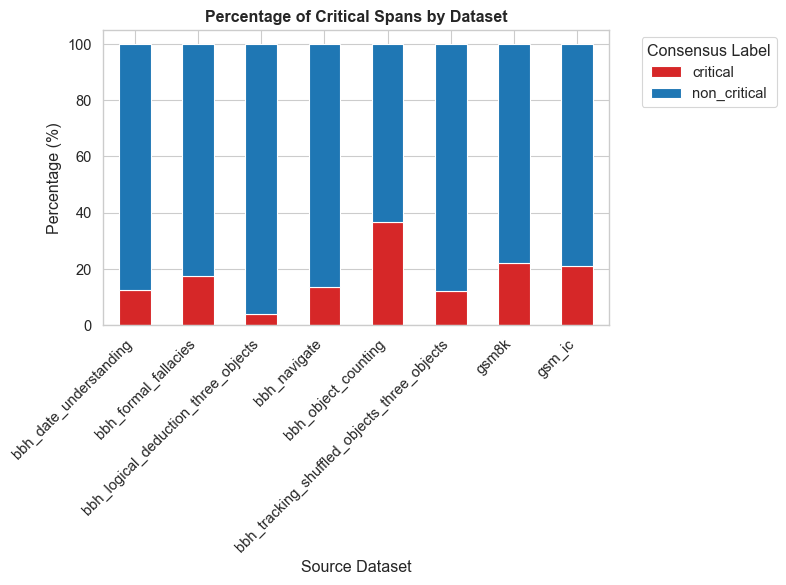

/var/folders/k4/kytnvzr91yl2jb_dn_w7m6240000gn/T/ipykernel_55813/4076544451.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_scores, x='agreement_score', y='span_category', palette='viridis')


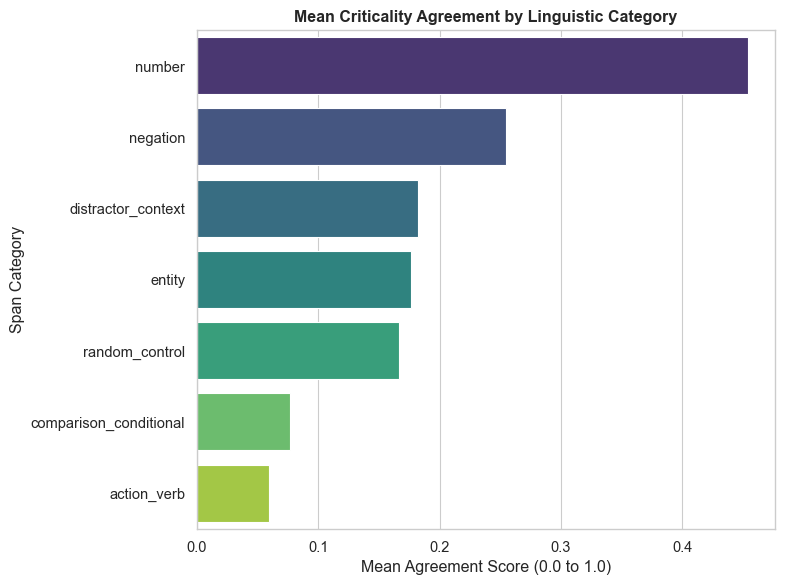

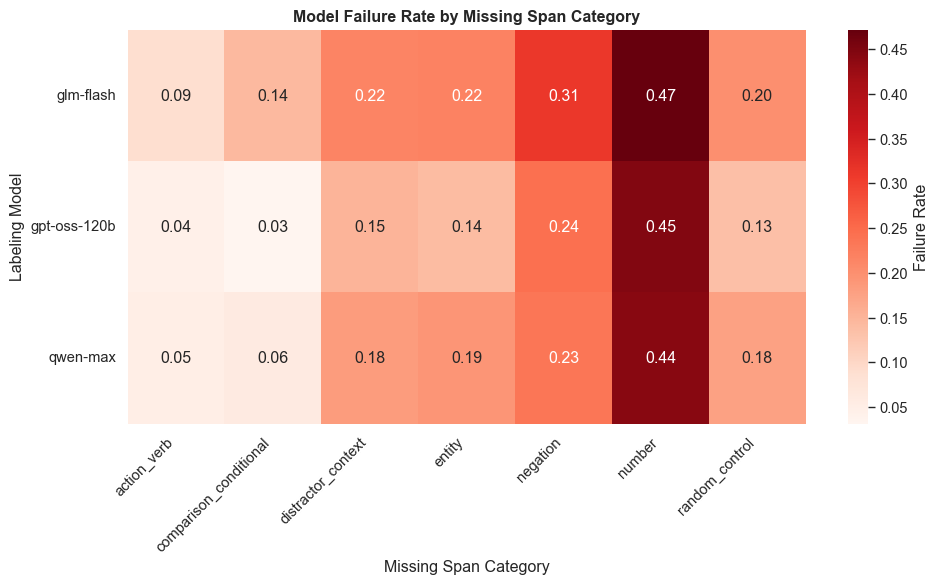

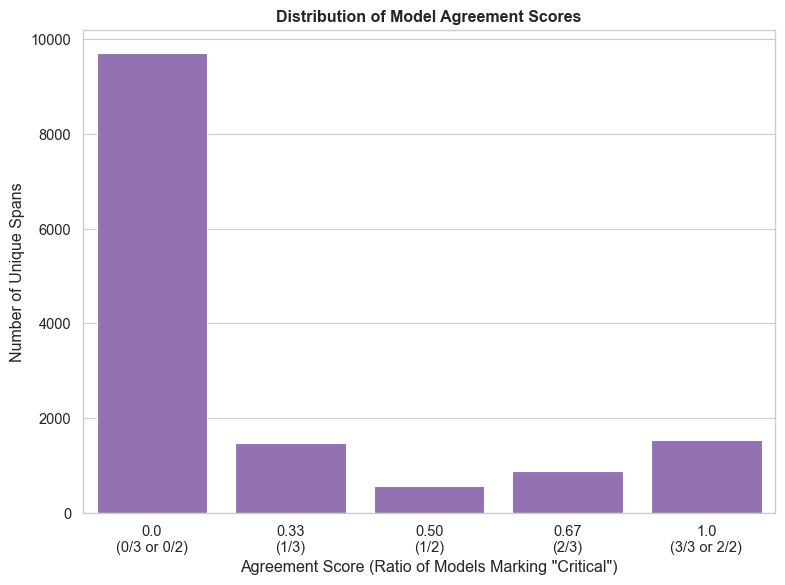

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional academic styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Load data
df = pd.read_csv("../data/consensus_dataset.csv")

# Clean up model names to prevent axis label overlaps in the heatmap
model_name_mapping = {
    'qwen3.7-max': 'qwen-max',
    'glm-5.3-flash': 'glm-flash',
    'openai/gpt-oss-120b': 'gpt-oss-120b',
    'gemini-3.6-flash': 'gemini-flash'
}
df['labeling_model'] = df['labeling_model'].replace(model_name_mapping)

# Create a unique-span dataframe for consensus-level plots
unique_spans = df.drop_duplicates(subset=["example_id", "span_start", "span_end"]).copy()


# ---------------------------------------------------------
# 1. Criticality by Dataset (100% Stacked Bar)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
dataset_crosstab = pd.crosstab(unique_spans['source_dataset'], unique_spans['consensus_label'], normalize='index') * 100
dataset_crosstab.plot(kind='bar', stacked=True, color=['#d62728', '#1f77b4'], ax=plt.gca())

plt.title('Percentage of Critical Spans by Dataset', fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Source Dataset')
plt.xticks(rotation=45, ha='right')
# Move legend slightly outside to avoid covering bars
plt.legend(title='Consensus Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("../outputs/eda_1_dataset_criticality.png", dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 2. Vulnerability by Linguistic Category (Horizontal Bar)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
category_scores = unique_spans.groupby('span_category')['agreement_score'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=category_scores, x='agreement_score', y='span_category', palette='viridis')

plt.title('Mean Criticality Agreement by Linguistic Category', fontweight='bold')
plt.xlabel('Mean Agreement Score (0.0 to 1.0)')
plt.ylabel('Span Category')

plt.tight_layout()
plt.savefig("../outputs/eda_2_linguistic_category.png", dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 3. Model-Specific Fragility (Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
df['failed_perturbation'] = ~df['is_correct_perturbed']
heatmap_data = df.pivot_table(index='labeling_model', columns='span_category', values='failed_perturbation', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds", cbar_kws={'label': 'Failure Rate'})

plt.title('Model Failure Rate by Missing Span Category', fontweight='bold')
plt.xlabel('Missing Span Category')
plt.ylabel('Labeling Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("../outputs/eda_3_model_fragility.png", dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 4. Consensus Agreement Distribution (Countplot)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
unique_spans['rounded_score'] = unique_spans['agreement_score'].round(2)
ax = sns.countplot(data=unique_spans, x='rounded_score', color='#9467bd')

plt.title('Distribution of Model Agreement Scores', fontweight='bold')
plt.xlabel('Agreement Score (Ratio of Models Marking "Critical")')
plt.ylabel('Number of Unique Spans')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['0.0\n(0/3 or 0/2)', '0.33\n(1/3)', '0.50\n(1/2)', '0.67\n(2/3)', '1.0\n(3/3 or 2/2)'])

plt.tight_layout()
plt.savefig("../outputs/eda_4_consensus_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## Part 3 : Granular Post-Perturbation Accuracy (Model × Dataset × Category)

While the previous analysis highlighted broad trends in span criticality, model architectures often display distinct biases depending on the specific task domain. 

To map these domain-specific vulnerabilities, the following faceted heatmaps break down the **post-perturbation accuracy** across three dimensions: the specific LLM, the source dataset, and the ablated linguistic category. This allows us to answer nuanced questions, such as whether a model's reliance on action verbs shifts when transitioning from mathematical reasoning (GSM8K) to logical deduction (BBH).

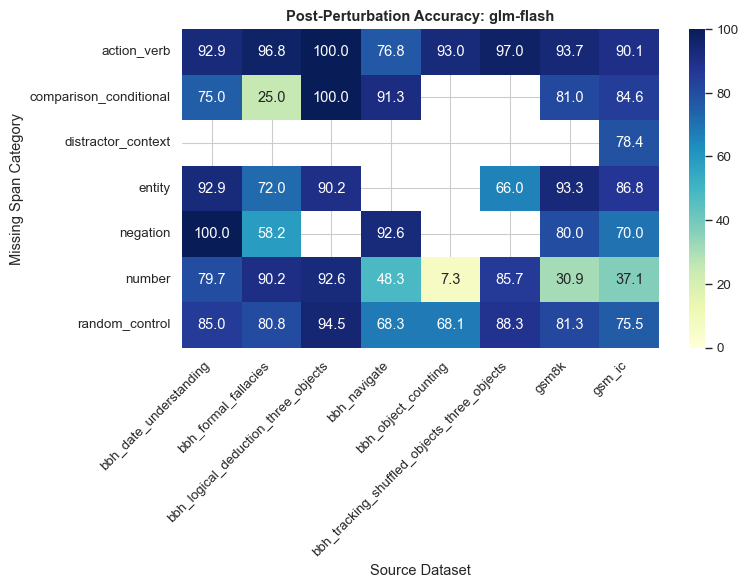

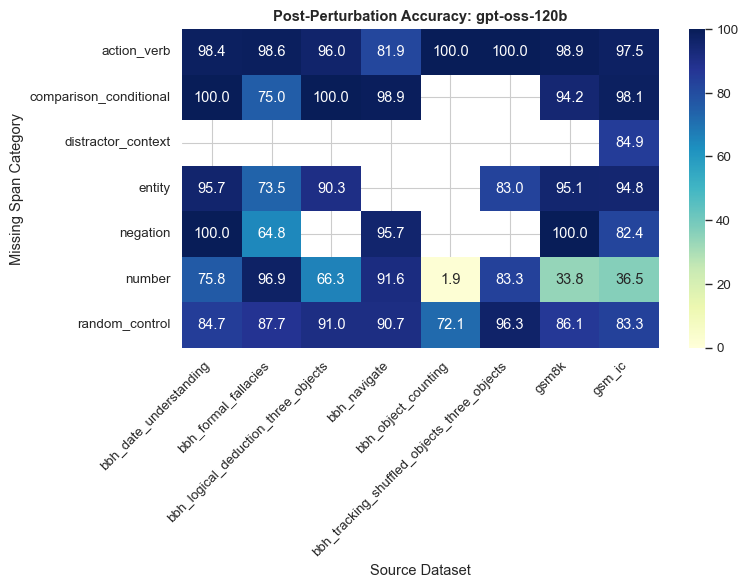

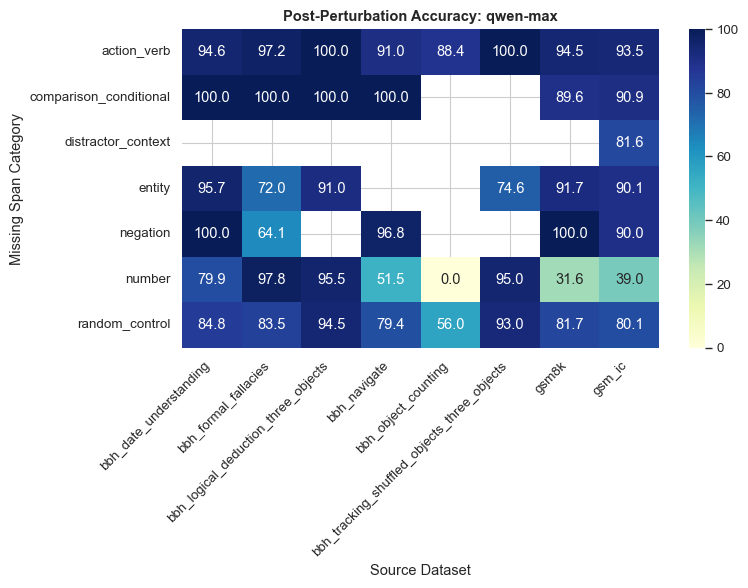

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Load data
df = pd.read_csv("../data/consensus_dataset.csv")

# Clean up model names to match the previous charts and prevent long titles
model_name_mapping = {
    'qwen3.7-max': 'qwen-max',
    'glm-5.3-flash': 'glm-flash',
    'openai/gpt-oss-120b': 'gpt-oss-120b',
    'gemini-3.6-flash': 'gemini-flash'
}
df['labeling_model'] = df['labeling_model'].replace(model_name_mapping)

# Get unique models
models = df['labeling_model'].unique()

for model in models:
    # Create a new figure for each model
    plt.figure(figsize=(8, 6))
    
    # Filter data for the specific model
    model_data = df[df['labeling_model'] == model]
    
    # Create a pivot table: Rows = Category, Columns = Dataset, Values = Accuracy (%)
    pivot = model_data.pivot_table(
        index='span_category', 
        columns='source_dataset', 
        values='is_correct_perturbed', 
        aggfunc='mean'
    ) * 100
    
    # Plot the individual heatmap
    sns.heatmap(
        pivot, 
        annot=True, 
        fmt=".1f", 
        cmap="YlGnBu",
        cbar=True, # Enable the color bar on all individual plots
        vmin=0, 
        vmax=100
    )
    
    # Formatting
    plt.title(f'Post-Perturbation Accuracy: {model}', fontweight='bold')
    plt.xlabel('Source Dataset')
    plt.ylabel('Missing Span Category')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # Clean the model name for safe file saving
    safe_model_name = model.replace("/", "_")
    plt.savefig(f"../outputs/granular_accuracy_{safe_model_name}.png", dpi=300, bbox_inches='tight')
    plt.show()